In [148]:
import scipy as sp
#from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, factorial
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, pi, exp, conj, argmin, unravel_index, log, einsum, tan, log10
import torch
import warnings
warnings.filterwarnings("ignore")
from utils import h_z_cpa, h_z_cpa_denominator, h_z_cpa_numerator, e_z_cpa, e_z_cpa_numerator, hl2_prime, hl1_prime, hbar, c, alpha, graphene_conductivity

### This notebook reproduces select figures from the following paper: [Spaser and optical amplification conditions in graphene-coated active wires](https://opg.optica.org/josab/fulltext.cfm?uri=josab-38-7-2118), published in 2021 in JOSA B.

### Figure 1 displays the resonant frequencies as $\omega/c$ in units of $\mu m^{-1}$. Note that $\hbar\omega=(\omega/c)\times(\hbar c)\approx (0.2)(\omega/c)\text{eV}$ (only if $\omega/c$ is given in units of $\mu m^{-1}$)

In [149]:
epsilon_F = 0.3 # Fermi energy in eV
gamma = 1e-4 # Scattering rate in eV
epsilon = 4.9 # Permittivity of the bulk
R = 0.5 # Radius in microns
N_omega_over_c = 1000 # Number of sampled frequency points
omega_over_c_real = linspace(0.1223, 0.12234, N_omega_over_c) # Re(omega/c)
omega_over_c_real_reshaped = np.repeat(np.reshape(omega_over_c_real, (N_omega_over_c, 1)), N_omega_over_c, axis=1)
omega_over_c_imag = linspace(-3.5e-4, 7.5e-4, N_omega_over_c) # Im(omega/c)
omega_over_c_imag_reshaped = np.repeat(np.reshape(omega_over_c_imag, (1, N_omega_over_c)), N_omega_over_c, axis=0)
omega_over_c_mat = omega_over_c_real_reshaped + 1j* omega_over_c_imag_reshaped
sigmas_mat = graphene_conductivity(epsilon_F, (hbar*c/1000) * omega_over_c_mat, gamma, include_interband=False);

In [150]:
l = 1
N_epsilons = 100
epsilons_imag = linspace(-0.1, 0, N_epsilons)
resonance_omegas_real = zeros(N_epsilons)
resonance_omegas_imag = zeros(N_epsilons)
x_mat = R * omega_over_c_mat

for (epsilon_imag_idx, epsilon_imag) in enumerate(epsilons_imag):
    resonances = h_z_cpa_denominator(l, x_mat, epsilon + 1j*epsilon_imag, -1j*sigmas_mat);
    resonance_omega = omega_over_c_mat.flatten()[np.abs(resonances).argmin()]
    resonance_omegas_real[epsilon_imag_idx] = resonance_omega.real
    resonance_omegas_imag[epsilon_imag_idx] = resonance_omega.imag

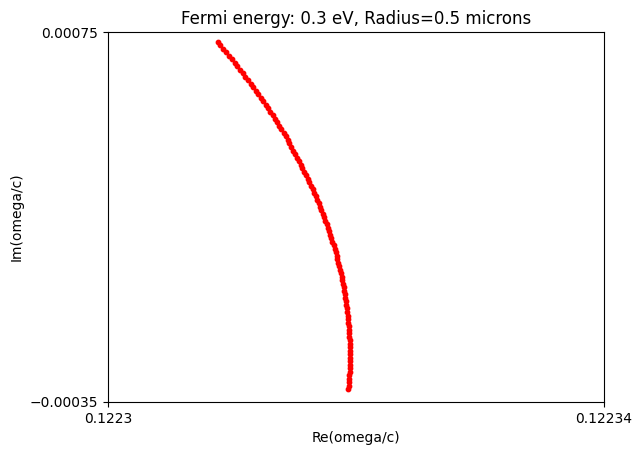

In [152]:
s = 10
plt.scatter(resonance_omegas_real, resonance_omegas_imag, color="red", s=s) 
plt.xlim(omega_over_c_real.min(), omega_over_c_real.max())
plt.ylim(omega_over_c_imag.min(), omega_over_c_imag.max());
plt.yticks([omega_over_c_imag.min(), omega_over_c_imag.max()])
plt.xticks([omega_over_c_real.min(), omega_over_c_real.max()], [omega_over_c_real.min(), omega_over_c_real.max()]);
plt.xlabel("Re(omega/c)")
plt.ylabel("Im(omega/c)")
plt.title(f"Fermi energy: {epsilon_F} eV, Radius={R} microns");